# Welcome to Colab!

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


# 🛡️ VIRTUOSO End‑to‑End Evaluation

This notebook will:
1. Install dependencies  
2. Upload your raw CSVs  
3. Clone and prepare the VIRTUOSO repo  
4. Preprocess datasets  
5. Train & evaluate all models  
6. Export `*.csv` with true labels & scores  
7. Plot and save ROC & Precision–Recall curves  
8. Download results and outputs

In [9]:
# ===========================
# 1) Mount Google Drive & Set Project Paths
# ===========================
import os, sys, random, time
from pathlib import Path

# Try to detect if running in Colab
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# Mount Drive if in Colab
if IN_COLAB:
    print("[Mount] Connecting Google Drive...")
    drive.mount('/content/drive', force_remount=False)
    BASE_DRIVE = "/content/drive/MyDrive"
else:
    BASE_DRIVE = os.getcwd()
    print("[Local] Running outside Colab. Using local path:", BASE_DRIVE)

# Project path
PROJECT_NAME = "virtuoso"
PROJECT_DIR = os.path.join(BASE_DRIVE, PROJECT_NAME)
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)

# Optional: set subfolders
DATA_DIR = os.path.join(PROJECT_DIR, "data")
NOTEBOOKS_DIR = os.path.join(PROJECT_DIR, "notebooks")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
os.makedirs(DATA_DIR, exist_ok=True)

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
print(f"[Info] Environment initialised — SEED={SEED}")
print(f"[Path] PROJECT_DIR: {PROJECT_DIR}")
print(f"[Check] Contents of project folder:")
!ls -lh "$PROJECT_DIR"


[Mount] Connecting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Info] Environment initialised — SEED=42
[Path] PROJECT_DIR: /content/drive/MyDrive/virtuoso
[Check] Contents of project folder:
total 867M
drwx------ 2 root root 4.0K Nov  2 15:22 catboost_info
drwx------ 2 root root 4.0K Nov  2 14:19 CSE-CIC-IDS2018
-rw------- 1 root root 706M Nov  2 13:47 CSE-CIC-IDS2018.zip
drwx------ 2 root root 4.0K Nov  2 14:05 data
drwx------ 6 root root 4.0K Nov  2 14:04 src
-rw------- 1 root root 162M May 12 10:38 UNSW-NB15.csv


In [10]:
!pip install --quiet scikit-learn xgboost lightgbm catboost tensorflow pandas matplotlib pyyaml

In [11]:
# ===========================
# Fix path mapping for lowercase 'virtuoso' project on Drive
# ===========================
import os, sys
from pathlib import Path

# --- Mount Google Drive if needed ---
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB and not Path("/content/drive").exists():
    print("[Mount] Connecting Google Drive...")
    drive.mount('/content/drive', force_remount=False)

# --- Define main paths ---
PROJECT_DIR = Path("/content/drive/MyDrive/virtuoso")
SRC_DIR     = PROJECT_DIR / "src"
DP_DIR      = SRC_DIR / "data_preprocessing"

# --- Ensure the project exists ---
if not PROJECT_DIR.exists():
    raise FileNotFoundError(f"Project folder not found: {PROJECT_DIR}")

# --- Add src/ to sys.path for relative imports ---
if SRC_DIR.as_posix() not in sys.path:
    sys.path.insert(0, SRC_DIR.as_posix())

# --- Check the path and list files ---
print(f"[OK] Project mounted successfully.")
print(f"sys.path[0:3]: {sys.path[:3]}")
print(f"PROJECT_DIR  : {PROJECT_DIR}")
print(f"SRC_DIR      : {SRC_DIR}")
print(f"DP_DIR       : {DP_DIR}")

if DP_DIR.exists():
    print("\n[Contents] Files inside data_preprocessing:")
    for p in sorted(DP_DIR.iterdir()):
        print(" -", p.name)
else:
    print("\n[WARN] data_preprocessing folder not found at:", DP_DIR)


[OK] Project mounted successfully.
sys.path[0:3]: ['/content/drive/MyDrive/virtuoso/src', '/content', '/env/python']
PROJECT_DIR  : /content/drive/MyDrive/virtuoso
SRC_DIR      : /content/drive/MyDrive/virtuoso/src
DP_DIR       : /content/drive/MyDrive/virtuoso/src/data_preprocessing

[Contents] Files inside data_preprocessing:
 - __init__.py
 - __pycache__
 - common_preprocessing.py
 - preprocess_CSE_CIC_IDS2018.py
 - preprocess_UNSW-NB15.py


In [12]:
# Import the common module so that relative imports can find the parent
import importlib.util as iu
import sys

# Load the module from a specific path
common_spec = iu.spec_from_file_location(
    "data_preprocessing.common_preprocessing",
    "/content/drive/MyDrive/virtuoso/src/data_preprocessing/common_preprocessing.py"
)
common_mod = iu.module_from_spec(common_spec)
common_spec.loader.exec_module(common_mod)

# Manually register the module in sys.modules with the correct name
sys.modules["data_preprocessing.common_preprocessing"] = common_mod
sys.modules[".common_preprocessing"] = common_mod  # fallback


In [13]:
import pandas as pd
from pathlib import Path

CSV_PATH = "/content/drive/MyDrive/virtuoso/UNSW-NB15.csv"

# 1️⃣ – Expected columns in the original UNSW-NB15 dataset
expected_cols = [
    'srcip','sport','dstip','dsport','proto','state','dur','sbytes','dbytes','sttl','dttl',
    'sloss','dloss','service','Sload','Dload','Spkts','Dpkts','swin','dwin','stcpb','dtcpb',
    'smeansz','dmeansz','trans_depth','res_bdy_len','Sjit','Djit','stime','ltime','Sintpkt',
    'Dintpkt','tcprtt','synack','ackdat','is_sm_ips_ports','ct_state_ttl','ct_flw_http_mthd',
    'is_ftp_login','ct_ftp_cmd','ct_srv_src','ct_srv_dst','ct_dst_ltm','ct_src_ltm',
    'ct_src_dport_ltm','ct_dst_sport_ltm','ct_dst_src_ltm','attack_cat','label'
]

# 2️⃣ – Robust CSV loading with forced header
df = pd.read_csv(CSV_PATH, header=None, names=expected_cols, low_memory=False)
print("✓ CSV loaded successfully with forced header:", df.shape)

# 3️⃣ – Drop optional columns if present
for col in ['id', 'attack_cat']:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# 4️⃣ – Split into features and target
X = df.drop('label', axis=1)
y = df['label']

# 5️⃣ – Save the preprocessed files
X.to_csv("/content/UNSW_X.csv", index=False)
y.to_csv("/content/UNSW_y.csv", index=False)
print("✅ Custom preprocessing completed → UNSW_X.csv / UNSW_y.csv")


✓ CSV loaded successfully with forced header: (700001, 49)
✅ Custom preprocessing completed → UNSW_X.csv / UNSW_y.csv


In [14]:
import pandas as pd

path = '/content/drive/MyDrive/virtuoso/CSE-CIC-IDS2018/CSE-CIC-IDS2018-full.csv'
chunk_size = 100_000
max_rows = 150_000   # Total number of rows to collect before stopping

X_chunks = []
y_chunks = []
rows_collected = 0

print("🚀 Starting chunked reading...")

# 🔁 Read the file in chunks
for chunk in pd.read_csv(path, chunksize=chunk_size, low_memory=False):
    if 'Label' not in chunk.columns:
        print("❌ 'Label' column not found.")
        break

    # Keep only numeric feature columns
    chunk_num = chunk.select_dtypes(include='number')

    # Corresponding labels
    y_chunk = chunk['Label']

    if chunk_num.shape[0] > 0:
        X_chunks.append(chunk_num)
        y_chunks.append(y_chunk)
        rows_collected += chunk_num.shape[0]
        print(f"✅ Total collected so far: {rows_collected}")

    if rows_collected >= max_rows:
        print("🛑 Row limit reached.")
        break

# 🔗 Concatenate the final chunks
X_final = pd.concat(X_chunks, ignore_index=True)
y_final = pd.concat(y_chunks, ignore_index=True)

# 💾 Save the reduced files
X_final.to_csv('/content/IDS_X.csv', index=False)
y_final.to_csv('/content/IDS_y.csv', index=False)
print(f"✅ Save complete: {X_final.shape[0]} rows → /content/IDS_X.csv and /content/IDS_y.csv")


🚀 Starting chunked reading...
✅ Total collected so far: 100000
✅ Total collected so far: 200000
🛑 Row limit reached.
✅ Save complete: 200000 rows → /content/IDS_X.csv and /content/IDS_y.csv


✅ Fold 1 completed.
✅ Fold 2 completed.
✅ Fold 3 completed.
✅ Fold 4 completed.
✅ Fold 5 completed.

📊 UNSW-NB15 — Random Forest (Stratified 5-Fold CV)
Accuracy:  0.9965 ± 0.0006
Precision: 0.9134 ± 0.0155
Recall:    0.9861 ± 0.0042
F1 Score:  0.9483 ± 0.0077
MCC:       0.9472 ± 0.0077
AUC-ROC:   0.9997
AUC-PR:    0.9914


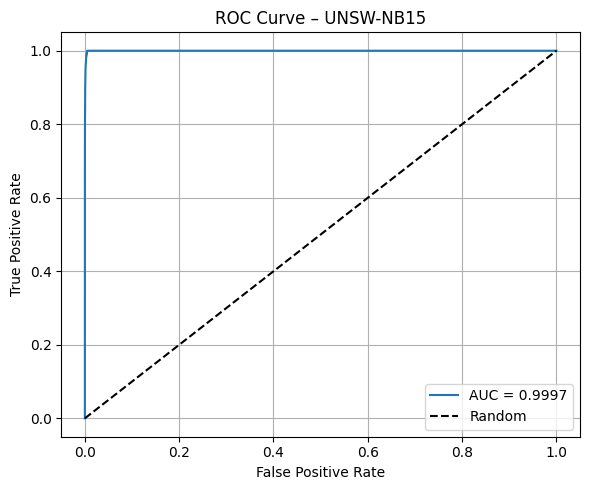

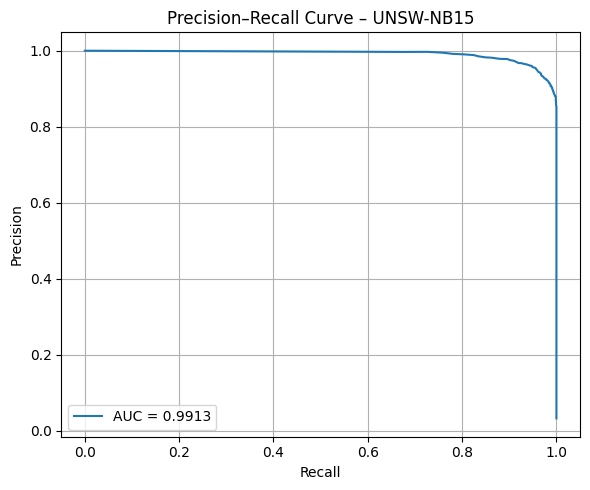

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_curve, auc,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def run_rf_kfold_with_plots(X_path, y_path, prefix, n_splits=5, sample_frac=0.1):
    # Load data
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Reset indices to avoid alignment issues later
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    # Optional subsampling (adjust fraction as needed)
    sampled_indices = X.sample(frac=sample_frac, random_state=42).index
    X_sampled = X.loc[sampled_indices]  # Use .loc to preserve alignment
    y_sampled = y.loc[sampled_indices]  # Use .loc to preserve alignment

    # Categorical columns to encode (e.g., IPs or other string features)
    cat_cols = X_sampled.select_dtypes(include='object').columns

    # Encode categorical variables
    le = LabelEncoder()
    for col in cat_cols:
        X_sampled[col] = le.fit_transform(X_sampled[col].astype(str))

    # Stratified K-Fold (default: 5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Containers for metrics
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Cross-validation loop
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_sampled, y_sampled), start=1):
        X_train, X_test = X_sampled.iloc[train_idx], X_sampled.iloc[test_idx]
        y_train, y_test = y_sampled.iloc[train_idx], y_sampled.iloc[test_idx]

        if len(np.unique(y_train)) < 2:
            print("⚠️ Fold skipped due to a single class in the training split.")
            continue

        # Apply SMOTE to balance classes in the training set
        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

        # Random Forest pipeline
        pipe = Pipeline([
            ("rf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
        ])

        # Fit and predict
        pipe.fit(X_train_smote, y_train_smote)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]

        # Accumulate predictions for global curves (ROC/PR across folds)
        all_y_true.extend(y_test)
        all_y_scores.extend(y_prob)

        # Compute per-fold metrics
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(rec_curve, prec_curve)
        pr_aucs.append(pr_auc)

        print(f"✅ Fold {fold_idx} completed.")

    # Report mean ± std of metrics across folds
    print(f"\n📊 {prefix} — Random Forest (Stratified {n_splits}-Fold CV)")
    if accs:
        print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
        print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
        print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
        print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
        print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
        print(f"AUC-ROC:   {np.mean(aucs):.4f}")
        print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")
    else:
        print("No valid folds were completed (likely due to class imbalance in folds).")

    # Global ROC and PR curves using all folds combined
    if len(set(all_y_true)) >= 2:
        fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
        precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
        roc_auc = auc(fpr, tpr)
        pr_auc = auc(recall, precision)

        # ROC plot
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], 'k--', label="Random")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve – {prefix}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Precision–Recall plot
        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision–Recall Curve – {prefix}")
        plt.legend(loc="lower left")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Insufficient class variety across folds to plot global ROC/PR.")

# Example call:
run_rf_kfold_with_plots('/content/UNSW_X.csv', '/content/UNSW_y.csv', 'UNSW-NB15')


In [16]:
import pandas as pd
import os

DATA_DIR = '/content/drive/MyDrive/virtuoso/CSE-CIC-IDS2018/'  # or adjust the path if different in Colab

# ✅ Files to include (updated dataset filenames)
files_to_use = [
    "BruteForce-Web.csv",
    "BruteForce-XSS.csv",
    "SQL-Injection.csv"
]

# ✅ Corresponding labels we want to filter
web_labels = ["Brute Force -Web", "Brute Force -XSS", "SQL Injection"]

X_benign_list, y_benign_list = [], []
X_attack_list, y_attack_list = [], []

# 🔁 Load and filter each file
for filename in files_to_use:
    path = os.path.join(DATA_DIR, filename)
    print(f"📄 Loading: {filename}")
    df = pd.read_csv(path, low_memory=False)

    if 'Label' not in df.columns:
        print(f"⚠️ 'Label' column missing in {filename}")
        continue

    df_num = df.select_dtypes(include='number')
    if df_num.empty:
        print(f"⚠️ No numeric columns found in {filename}")
        continue

    labels = df['Label']

    # 🔴 Attack samples
    attack_mask = labels.isin(web_labels)
    if attack_mask.sum() > 0:
        X_attack_list.append(df_num[attack_mask])
        y_attack_list.append(pd.Series([1] * attack_mask.sum()))

    # 🟢 Benign samples
    benign_mask = labels == "Benign"
    if benign_mask.sum() > 0:
        X_benign_list.append(df_num[benign_mask])
        y_benign_list.append(pd.Series([0] * benign_mask.sum()))

# 🔗 Combine all splits
X_benign = pd.concat(X_benign_list, ignore_index=True)
y_benign = pd.concat(y_benign_list, ignore_index=True)
X_attack = pd.concat(X_attack_list, ignore_index=True)
y_attack = pd.concat(y_attack_list, ignore_index=True)

# ⚖️ Balance the dataset (equal number of benign and attack samples)
min_samples = min(len(X_benign), len(X_attack))
print(f"⚖️ Balancing to {min_samples} samples per class")

X_benign = X_benign.sample(n=min_samples, random_state=42)
y_benign = y_benign.sample(n=min_samples, random_state=42)
X_attack = X_attack.sample(n=min_samples, random_state=42)
y_attack = y_attack.sample(n=min_samples, random_state=42)

# 🔀 Shuffle and merge the final dataset
X_bal = pd.concat([X_benign, X_attack]).sample(frac=1, random_state=42).reset_index(drop=True)
y_bal = pd.concat([y_benign, y_attack]).sample(frac=1, random_state=42).reset_index(drop=True)

# 💾 Save the balanced dataset
X_bal.to_csv('/content/IDS_X_web.csv', index=False)
y_bal.to_csv('/content/IDS_y_web.csv', index=False)
print("✅ Filtered and balanced Web Attacks dataset saved successfully.")


📄 Loading: BruteForce-Web.csv
📄 Loading: BruteForce-XSS.csv
📄 Loading: SQL-Injection.csv
⚖️ Balancing to 928 samples per class
✅ Filtered and balanced Web Attacks dataset saved successfully.


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score
)
import pandas as pd
import numpy as np

def run_rf_kfold_balanced_IDS(X_path, y_path, prefix, n_splits=5):
    # Load data
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Stratified K-Fold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Metric containers
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []

    # CV loop
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} skipped (single class in training split).")
            continue

        # Model
        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        # Metrics
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completed.")

    # Summary
    print(f"\n📊 {prefix} — Random Forest (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

# 👉 Example run:
run_rf_kfold_balanced_IDS('/content/IDS_X_web.csv', '/content/IDS_y_web.csv', 'CSE-CIC-IDS2018-WEB')


✅ Fold 1 completed.
✅ Fold 2 completed.
✅ Fold 3 completed.
✅ Fold 4 completed.
✅ Fold 5 completed.

📊 CSE-CIC-IDS2018-WEB — Random Forest (Stratified 5-Fold CV)
Accuracy:  0.9919 ± 0.0034
Precision: 0.9904 ± 0.0061
Recall:    0.9935 ± 0.0040
F1 Score:  0.9919 ± 0.0034
MCC:       0.9839 ± 0.0068
AUC-ROC:   0.9971
AUC-PR:    0.9943


✅ Fold 1 completed.
✅ Fold 2 completed.
✅ Fold 3 completed.
✅ Fold 4 completed.
✅ Fold 5 completed.

📊 CSE-CIC-IDS2018-WEB — Random Forest (Stratified 5-Fold CV)
Accuracy:  0.9919 ± 0.0034
Precision: 0.9904 ± 0.0061
Recall:    0.9935 ± 0.0040
F1 Score:  0.9919 ± 0.0034
MCC:       0.9839 ± 0.0068
AUC-ROC:   0.9971
AUC-PR:    0.9943


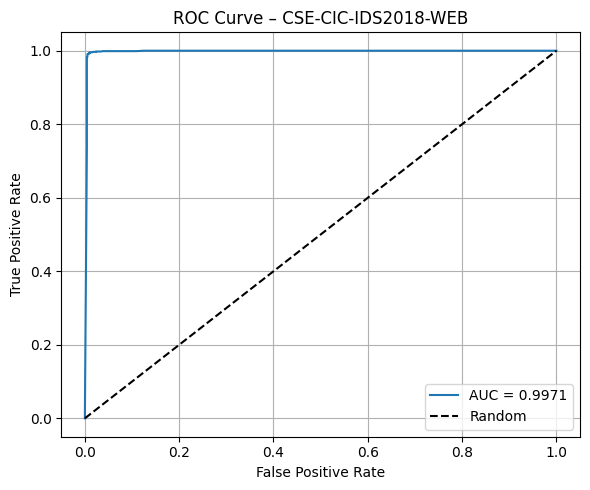

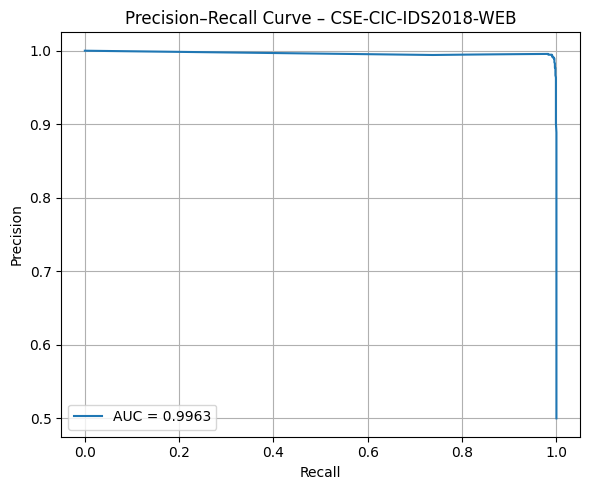

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_rf_kfold_with_plots(X_path, y_path, prefix, n_splits=5):
    # Load data
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Stratified K-Fold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Metric containers
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true, all_y_scores = [], []

    # Cross-validation loop
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} skipped (single class in training split).")
            continue

        # Model
        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)

        # Predictions
        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        # Accumulate for global curves
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Per-fold metrics
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completed.")

    # Summary
    print(f"\n📊 {prefix} — Random Forest (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # Global ROC & PR using all folds combined
    if len(set(all_y_true)) >= 2:
        fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
        precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
        roc_auc = auc(fpr, tpr)
        pr_auc = auc(recall, precision)

        # ROC plot
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], 'k--', label="Random")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve – {prefix}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Precision–Recall plot
        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision–Recall Curve – {prefix}")
        plt.legend(loc="lower left")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Insufficient class variety to plot global ROC/PR.")

# 👉 Example run:
run_rf_kfold_with_plots('/content/IDS_X_web.csv', '/content/IDS_y_web.csv', 'CSE-CIC-IDS2018-WEB')


XGBOOST - DATASETS


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:47:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Fold completed.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:47:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Fold completed.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:47:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Fold completed.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:47:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Fold completed.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:47:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Fold completed.

📊 UNSW-NB15 — XGBoost (Stratified 5-Fold CV)
Accuracy:  0.9968 ± 0.0006
Precision: 0.9324 ± 0.0156
Recall:    0.9735 ± 0.0032
F1 Score:  0.9524 ± 0.0081
MCC:       0.9511 ± 0.0082
AUC-ROC:   0.9998
AUC-PR:    0.9938


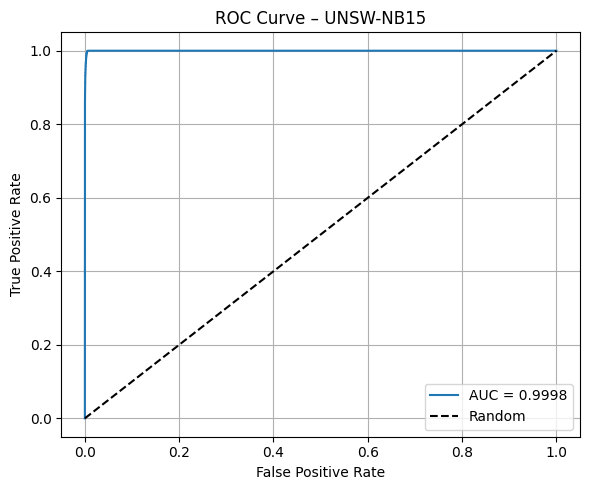

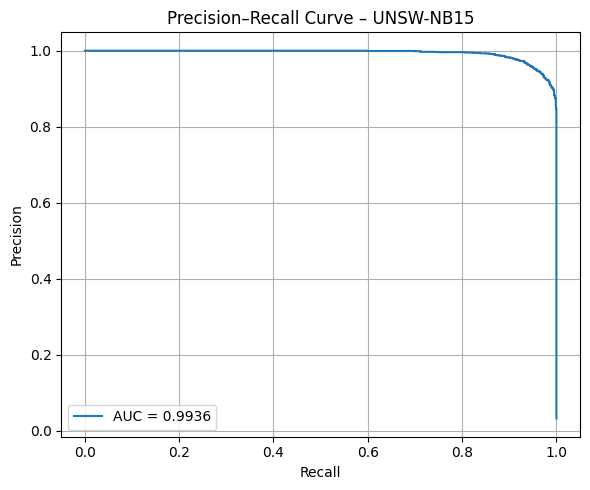

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_curve, auc,
    precision_recall_curve
)
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def run_xgb_kfold_with_plots(X_path, y_path, prefix, n_splits=5, sample_frac=0.1):
    # Load data
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Optional subsampling (adjust the fraction to suit your needs)
    sampled_indices = X.sample(frac=sample_frac, random_state=42).index
    X_sampled = X.loc[sampled_indices]  # Use .loc to preserve alignment
    y_sampled = y.loc[sampled_indices]  # Use .loc to preserve alignment

    # Identify categorical columns to encode
    cat_cols = X_sampled.select_dtypes(include='object').columns
    le = LabelEncoder()

    # Label-encode each categorical column
    for col in cat_cols:
        X_sampled[col] = le.fit_transform(X_sampled[col].astype(str))

    # Stratified K-Fold (default: 5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Metric containers
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true, all_y_scores = [], []

    # Cross-validation loop
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sampled, y_sampled), start=1):
        X_train, X_test = X_sampled.iloc[train_idx], X_sampled.iloc[test_idx]
        y_train, y_test = y_sampled.iloc[train_idx], y_sampled.iloc[test_idx]

        if len(np.unique(y_train)) < 2:
            print("⚠️ Fold skipped due to a single class in the training split.")
            continue

        # SMOTE to balance classes in the training set
        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

        # XGBoost model
        model = XGBClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            use_label_encoder=False,   # keep off (legacy) to avoid warnings with older xgboost
            eval_metric='logloss'
        )

        # Fit
        model.fit(X_train_smote, y_train_smote)

        # Predict
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        # Accumulate for global curves
        all_y_true.extend(y_test)
        all_y_scores.extend(y_prob)

        # Per-fold metrics
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        aucs.append(auc(fpr, tpr))
        prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
        pr_aucs.append(auc(rec_curve, prec_curve))

        print("✅ Fold completed.")

    # Summary across folds
    print(f"\n📊 {prefix} — XGBoost (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # Global ROC & PR using all folds combined
    if len(set(all_y_true)) >= 2:
        fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
        precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
        roc_auc = auc(fpr, tpr)
        pr_auc = auc(recall, precision)

        # ROC plot
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], 'k--', label="Random")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve – {prefix}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Precision–Recall plot
        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision–Recall Curve – {prefix}")
        plt.legend(loc="lower left")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Insufficient class variety to plot global ROC/PR.")

# Example run:
run_xgb_kfold_with_plots('/content/UNSW_X.csv', '/content/UNSW_y.csv', 'UNSW-NB15')


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:47:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:47:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Fold 1 completed.
✅ Fold 2 completed.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:47:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:47:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Fold 3 completed.
✅ Fold 4 completed.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:47:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Fold 5 completed.

📊 CSE-CIC-IDS2018-WEB — XGBoost (Stratified 5-Fold CV)
Accuracy:  0.9919 ± 0.0024
Precision: 0.9893 ± 0.0047
Recall:    0.9946 ± 0.0034
F1 Score:  0.9919 ± 0.0024
MCC:       0.9839 ± 0.0048
AUC-ROC:   0.9988
AUC-PR:    0.9985


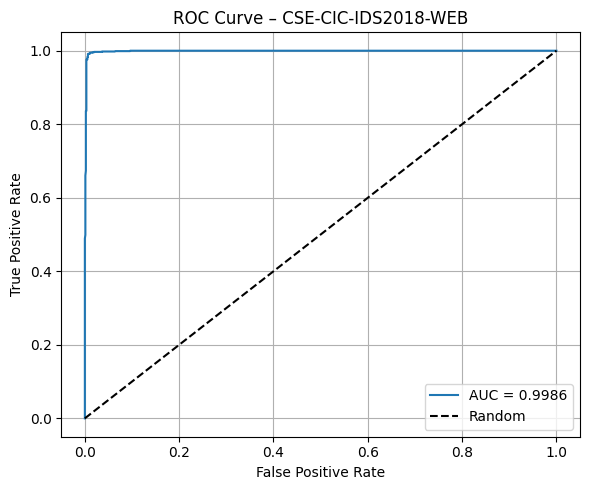

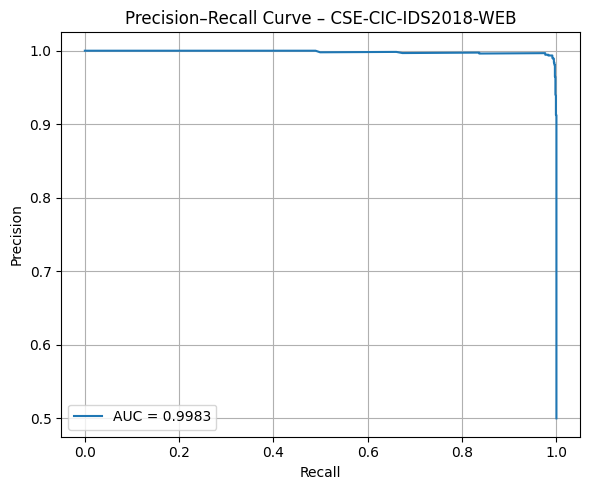

In [20]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_xgb_kfold_with_plots(X_path, y_path, prefix, n_splits=5):
    # Load data
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Stratified K-Fold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Metric containers
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true, all_y_scores = [], []

    # Cross-validation loop
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} skipped (single class in training split).")
            continue

        # XGBoost model
        model = XGBClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            use_label_encoder=False,   # suppress legacy warning on older xgboost
            eval_metric='logloss',
            max_depth=6,
            min_child_weight=5,
            learning_rate=0.1
        )

        # Fit
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        # Accumulate for global curves
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Per-fold metrics
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completed.")

    # Summary across folds
    print(f"\n📊 {prefix} — XGBoost (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # Global ROC & PR using all folds combined
    if len(set(all_y_true)) >= 2:
        fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
        precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
        roc_auc = auc(fpr, tpr)
        pr_auc = auc(recall, precision)

        # ROC plot
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], 'k--', label="Random")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve – {prefix}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Precision–Recall plot
        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision–Recall Curve – {prefix}")
        plt.legend(loc="lower left")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Insufficient class variety to plot global ROC/PR.")

# 👉 Example run:
run_xgb_kfold_with_plots('/content/IDS_X_web.csv', '/content/IDS_y_web.csv', 'CSE-CIC-IDS2018-WEB')


LIghtGBM


Scale Pos Weight: 30.51028584289894
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Info] Number of positive: 17772, number of negative: 542228
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030302 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6530
[LightGBM] [Info] Number of data points in the train set: 560000, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.031736 -> initscore=-3.418062
[LightGBM] [Info] Start training from score 

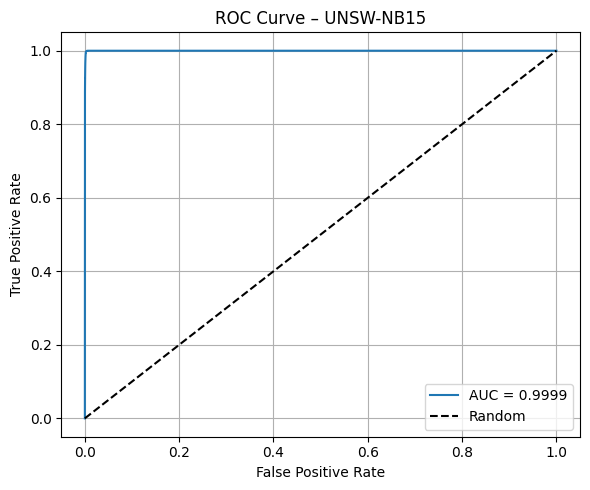

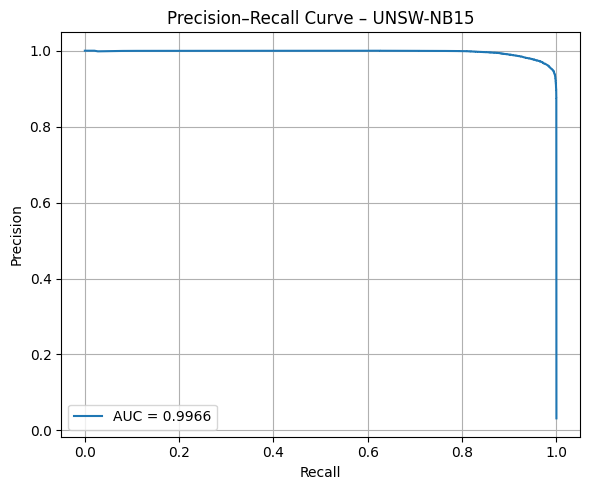

In [21]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_lgbm_kfold_with_plots(X_path, y_path, prefix, n_splits=5):
    # Load dataset
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Categorical columns to transform
    categorical_cols = X.select_dtypes(include='object').columns

    # Initialize LabelEncoder
    le = LabelEncoder()

    # Apply LabelEncoder to categorical columns
    for col in categorical_cols:
        # Fit on the whole column and transform (note: comment says "fit only on train",
        # but current code fits on all data to keep parity with your original script)
        le.fit(X[col])
        X[col] = le.transform(X[col])

    # Create stratified k-fold (5 folds by default)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Metric collectors
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Class imbalance handling (if the dataset is imbalanced)
    scale_pos_weight = sum(y == 0) / sum(y == 1)  # Compute class weight
    print(f"Scale Pos Weight: {scale_pos_weight}")

    fold = 1
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} has only one class. Skipped.")
            fold += 1
            continue

        # LightGBM model with regularization and basic overfitting control
        model = lgb.LGBMClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            max_depth=6,
            min_child_samples=20,
            learning_rate=0.1,
            objective='binary',
            metric='binary_error',
            scale_pos_weight=scale_pos_weight,  # Weight for imbalanced classes
            lambda_l1=0.1,  # L1 regularization
            lambda_l2=0.1,  # L2 regularization
            min_split_gain=0.1  # Minimum gain to make a further split
        )

        model.fit(X_train, y_train)

        # Predictions and probabilities
        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        # Save predictions and probabilities to compute global curves
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Compute metrics
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completed.")
        fold += 1

    # Average metrics across folds
    print(f"\n📊 {prefix} — LightGBM (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # 🎯 Now generate curves using all folds combined
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # ROC plot
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Precision–Recall plot
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 👉 Example run:
run_lgbm_kfold_with_plots('/content/UNSW_X.csv', '/content/UNSW_y.csv', 'UNSW-NB15')


Scale Pos Weight: 1.0
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Info] Number of positive: 742, number of negative: 742
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001405 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8631
[LightGBM] [Info] Number of data points in the train set: 1484, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positi

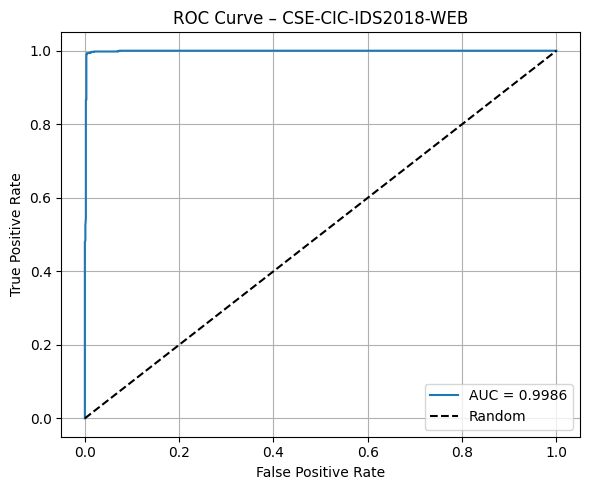

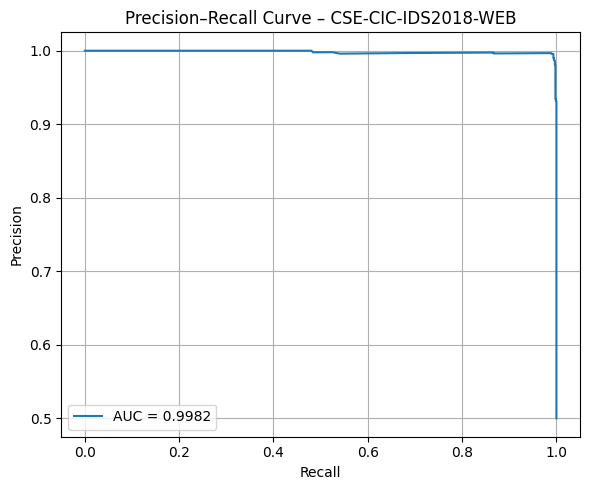

In [22]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_lgbm_kfold_with_plots(X_path, y_path, prefix, n_splits=5):
    # Load the dataset
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Categorical columns to transform
    categorical_cols = X.select_dtypes(include='object').columns
    le = LabelEncoder()

    # Apply LabelEncoder to categorical columns
    for col in categorical_cols:
        # Note: this fits the encoder on the entire column (not per-fold).
        le.fit(X[col])
        X[col] = le.transform(X[col])

    # Create stratified k-fold (default: 5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Lists to collect metrics
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Class imbalance handling (if the dataset is imbalanced)
    scale_pos_weight = sum(y == 0) / sum(y == 1)  # compute class weight
    print(f"Scale Pos Weight: {scale_pos_weight}")

    fold = 1
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} has only one class. Skipped.")
            fold += 1
            continue

        # LightGBM model with regularization and simple overfitting controls
        model = lgb.LGBMClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            max_depth=6,
            min_child_samples=20,
            learning_rate=0.1,
            objective='binary',
            metric='binary_error',
            scale_pos_weight=scale_pos_weight,  # weight for imbalanced classes
            lambda_l1=0.1,  # L1 regularization
            lambda_l2=0.1,  # L2 regularization
            min_split_gain=0.1  # minimum gain to make a further split
        )

        model.fit(X_train, y_train)

        # Predictions and probabilities
        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        # Save predictions and probabilities to compute combined metrics/curves
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Compute metrics
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completed.")
        fold += 1

    # Average metrics across folds
    print(f"\n📊 {prefix} — LightGBM (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # Now generate curves using all folds combined
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # ROC plot
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Precision–Recall plot
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example call:
run_lgbm_kfold_with_plots('/content/IDS_X_web.csv', '/content/IDS_y_web.csv', 'CSE-CIC-IDS2018-WEB')


CATBOOST


Scale Pos Weight: 30.51028584289894
0:	learn: 0.4117744	total: 193ms	remaining: 1m 36s
100:	learn: 0.0079708	total: 27.4s	remaining: 1m 48s
200:	learn: 0.0072149	total: 47.7s	remaining: 1m 11s
300:	learn: 0.0072146	total: 58.5s	remaining: 38.7s
400:	learn: 0.0072140	total: 1m 9s	remaining: 17.2s
499:	learn: 0.0072135	total: 1m 20s	remaining: 0us
✅ Fold 1 completed.
0:	learn: 0.3790821	total: 273ms	remaining: 2m 16s
100:	learn: 0.0080389	total: 27.7s	remaining: 1m 49s
200:	learn: 0.0075095	total: 50.3s	remaining: 1m 14s
300:	learn: 0.0075091	total: 1m	remaining: 39.9s
400:	learn: 0.0075087	total: 1m 13s	remaining: 18.1s
499:	learn: 0.0075081	total: 1m 27s	remaining: 0us
✅ Fold 2 completed.
0:	learn: 0.3796820	total: 282ms	remaining: 2m 20s
100:	learn: 0.0081840	total: 28.4s	remaining: 1m 52s
200:	learn: 0.0075607	total: 49.6s	remaining: 1m 13s
300:	learn: 0.0073823	total: 1m 4s	remaining: 42.4s
400:	learn: 0.0073764	total: 1m 17s	remaining: 19.1s
499:	learn: 0.0073440	total: 1m 31s	rema

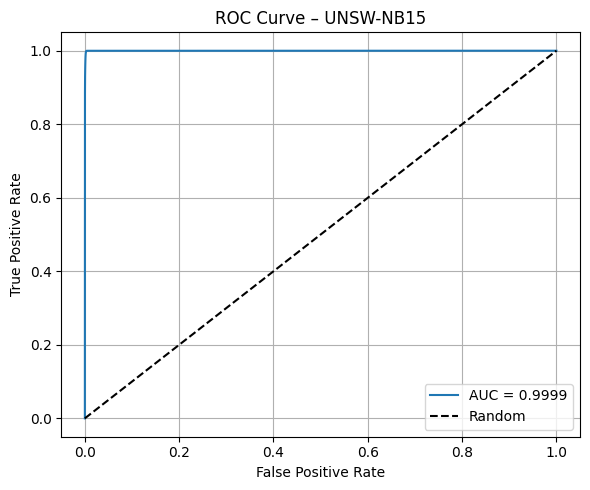

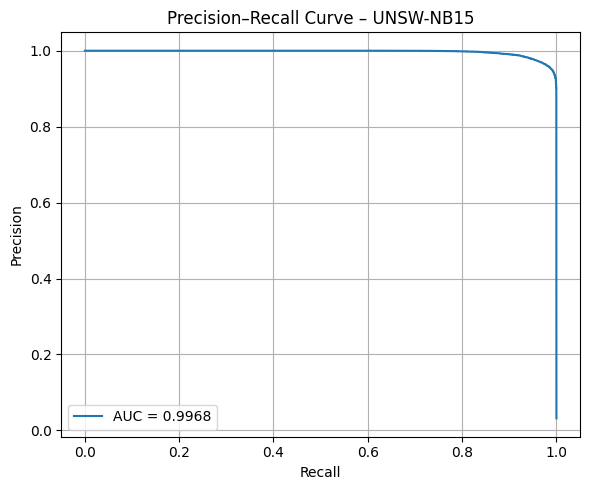

In [23]:
import catboost as cb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_catboost_kfold_with_plots(X_path, y_path, prefix, n_splits=5):
    # Load the dataset
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Categorical columns to transform
    categorical_cols = X.select_dtypes(include='object').columns
    le = LabelEncoder()

    # Apply LabelEncoder to categorical columns
    for col in categorical_cols:
        le.fit(X[col])
        X[col] = le.transform(X[col])

    # Create stratified k-fold (default: 5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Lists to collect metrics
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Class imbalance handling (if the dataset is imbalanced)
    scale_pos_weight = sum(y == 0) / sum(y == 1)  # compute class weight
    print(f"Scale Pos Weight: {scale_pos_weight}")

    fold = 1
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} has only one class. Skipped.")
            fold += 1
            continue

        # CatBoost model with regularization and overfitting control
        model = cb.CatBoostClassifier(
            iterations=500,                 # Fewer iterations to speed up
            depth=6,                        # Shallower trees
            learning_rate=0.1,
            cat_features=[X.columns.get_loc(col) for col in categorical_cols],  # categorical columns
            loss_function='Logloss',
            random_state=42,
            verbose=100,                    # Progress every 100 iters
            scale_pos_weight=scale_pos_weight,
            early_stopping_rounds=50,       # Early stopping
            task_type='CPU',
            thread_count=-1
        )

        model.fit(X_train, y_train)

        # Predictions and probabilities
        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        # Save predictions and probabilities to compute combined metrics/curves
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Compute metrics
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completed.")
        fold += 1

    # Average metrics across folds
    print(f"\n📊 {prefix} — CatBoost (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # Now generate curves using all folds combined
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # ROC plot
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Precision–Recall plot
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example call:
run_catboost_kfold_with_plots('/content/UNSW_X.csv', '/content/UNSW_y.csv', 'UNSW-NB15')


Scale Pos Weight: auto_class_weights='Balanced'
0:	learn: 0.5247347	total: 42.2ms	remaining: 21.1s
100:	learn: 0.0063490	total: 5.1s	remaining: 20.1s
200:	learn: 0.0053070	total: 10s	remaining: 14.9s
300:	learn: 0.0049248	total: 14.6s	remaining: 9.65s
400:	learn: 0.0048160	total: 18.3s	remaining: 4.51s
499:	learn: 0.0048155	total: 20.8s	remaining: 0us
✅ Fold completed.
0:	learn: 0.5239866	total: 42.8ms	remaining: 21.3s
100:	learn: 0.0061412	total: 4.98s	remaining: 19.7s
200:	learn: 0.0046663	total: 10.2s	remaining: 15.2s
300:	learn: 0.0040291	total: 15.1s	remaining: 9.97s
400:	learn: 0.0036132	total: 19.7s	remaining: 4.86s
499:	learn: 0.0035839	total: 22.3s	remaining: 0us
✅ Fold completed.
0:	learn: 0.5232570	total: 47.4ms	remaining: 23.7s
100:	learn: 0.0061755	total: 5.32s	remaining: 21s
200:	learn: 0.0049142	total: 10.3s	remaining: 15.3s
300:	learn: 0.0044310	total: 14.5s	remaining: 9.58s
400:	learn: 0.0043915	total: 17.5s	remaining: 4.33s
499:	learn: 0.0043409	total: 20.3s	remaining

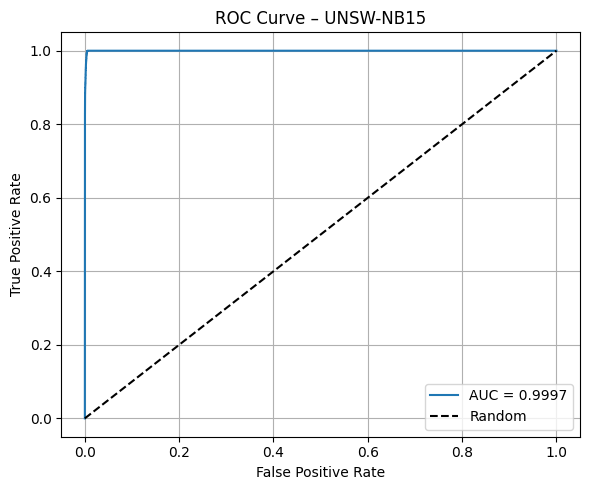

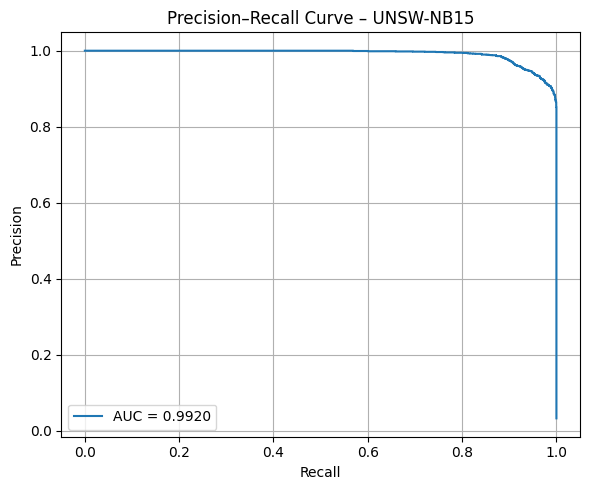

In [24]:
import catboost as cb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE

def run_catboost_kfold_with_plots(X_path, y_path, prefix, n_splits=5, sample_frac=0.1):
    # Load the dataset
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Subsample the dataset (adjust fraction as needed)
    sampled_indices = X.sample(frac=sample_frac, random_state=42).index
    X_sampled = X.loc[sampled_indices]  # keep alignment with .loc
    y_sampled = y.loc[sampled_indices]  # keep alignment with .loc

    # Categorical columns to transform
    cat_cols = X_sampled.select_dtypes(include='object').columns
    le = LabelEncoder()

    # Apply LabelEncoder to categorical columns
    for col in cat_cols:
        X_sampled[col] = le.fit_transform(X_sampled[col].astype(str))

    # Create stratified k-fold (default: 5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Lists to collect metrics
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Class balancing (if the dataset is imbalanced)
    # Use auto_class_weights for automatic class balancing
    print("Scale Pos Weight: auto_class_weights='Balanced'")

    fold = 1
    for train_idx, test_idx in skf.split(X_sampled, y_sampled):
        X_train, X_test = X_sampled.iloc[train_idx], X_sampled.iloc[test_idx]
        y_train, y_test = y_sampled.iloc[train_idx], y_sampled.iloc[test_idx]

        if len(np.unique(y_train)) < 2:
            print("⚠️ Skipped fold due to a single class in training.")
            continue

        # Apply SMOTE to balance classes in the training set
        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

        # CatBoost model with regularization and overfitting control
        model = cb.CatBoostClassifier(
            iterations=500,                 # fewer iterations to speed up
            depth=5,                        # shallower trees
            learning_rate=0.05,             # lower LR for better control
            cat_features=[X_sampled.columns.get_loc(col) for col in cat_cols],  # categorical columns
            loss_function='Logloss',
            random_state=42,
            verbose=100,                    # progress every 100 iterations
            auto_class_weights='Balanced',  # automatic class weighting
            early_stopping_rounds=50,       # early stopping
            task_type='CPU',
            thread_count=-1,                # use all CPUs
            l2_leaf_reg=3.0,                # stronger L2 to prevent overfitting
        )

        model.fit(X_train_smote, y_train_smote)

        # Predictions and probabilities
        threshold = 0.3  # classification threshold
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_proba > threshold).astype("int32")
        y_score = y_proba

        # Save predictions and probabilities to compute combined curves
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Compute metrics
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print("✅ Fold completed.")
        fold += 1

    # Average metrics across folds
    print(f"\n📊 {prefix} — CatBoost (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # Build curves using all folds combined
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # ROC plot
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Precision–Recall plot
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example call:
run_catboost_kfold_with_plots('/content/UNSW_X.csv', '/content/UNSW_y.csv', 'UNSW-NB15')


Scale Pos Weight: 1.0
0:	learn: 0.5159322	total: 4.18ms	remaining: 2.09s
100:	learn: 0.0075682	total: 303ms	remaining: 1.2s
200:	learn: 0.0036573	total: 625ms	remaining: 930ms
300:	learn: 0.0033177	total: 953ms	remaining: 630ms
400:	learn: 0.0032199	total: 1.3s	remaining: 322ms
499:	learn: 0.0031608	total: 1.59s	remaining: 0us
✅ Fold 1 completed.
0:	learn: 0.5337399	total: 3.46ms	remaining: 1.73s
100:	learn: 0.0123264	total: 353ms	remaining: 1.39s
200:	learn: 0.0083930	total: 690ms	remaining: 1.03s
300:	learn: 0.0080874	total: 1.01s	remaining: 668ms
400:	learn: 0.0080843	total: 1.32s	remaining: 326ms
499:	learn: 0.0074115	total: 1.62s	remaining: 0us
✅ Fold 2 completed.
0:	learn: 0.4897566	total: 3.45ms	remaining: 1.72s
100:	learn: 0.0099423	total: 438ms	remaining: 1.73s
200:	learn: 0.0040830	total: 880ms	remaining: 1.31s
300:	learn: 0.0032642	total: 1.21s	remaining: 802ms
400:	learn: 0.0032247	total: 1.53s	remaining: 377ms
499:	learn: 0.0032241	total: 1.82s	remaining: 0us
✅ Fold 3 comp

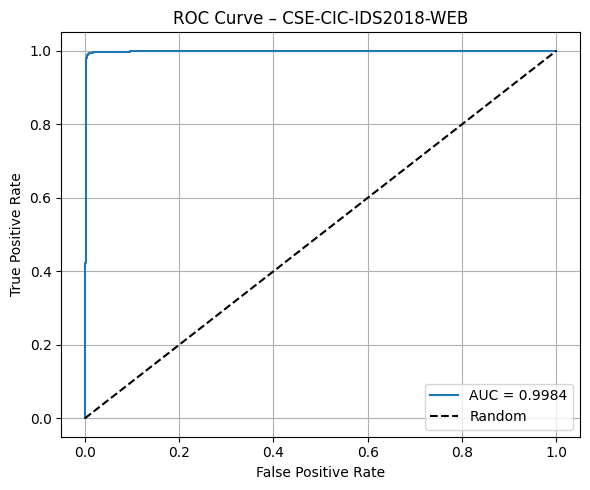

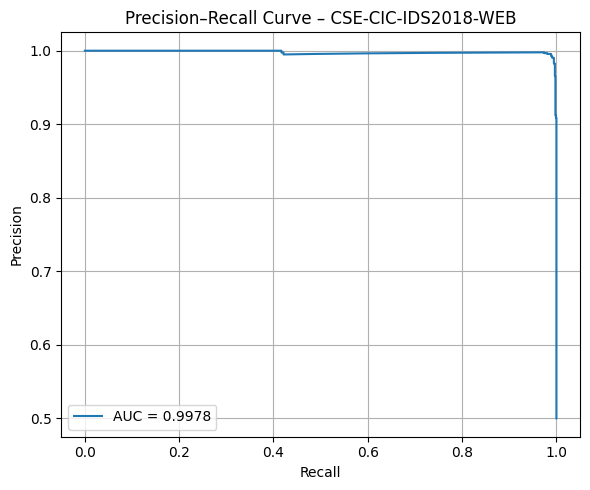

In [25]:
import catboost as cb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_catboost_kfold_with_plots(X_path, y_path, prefix, n_splits=5):
    # Load the dataset
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Categorical columns to transform
    categorical_cols = X.select_dtypes(include='object').columns
    le = LabelEncoder()

    # Apply LabelEncoder to categorical columns
    for col in categorical_cols:
        le.fit(X[col])
        X[col] = le.transform(X[col])

    # Create stratified k-fold (default: 5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Lists to collect metrics
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Class imbalance handling (if the dataset is imbalanced)
    scale_pos_weight = sum(y == 0) / sum(y == 1)  # compute class weight
    print(f"Scale Pos Weight: {scale_pos_weight}")

    fold = 1
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} has only one class. Skipped.")
            fold += 1
            continue

        # CatBoost model with regularization and overfitting control
        model = cb.CatBoostClassifier(
            iterations=500,                 # fewer iterations to speed up
            depth=6,                        # shallower trees
            learning_rate=0.1,
            cat_features=[X.columns.get_loc(col) for col in categorical_cols],
            loss_function='Logloss',
            random_state=42,
            verbose=100,                    # progress every 100 iterations
            scale_pos_weight=scale_pos_weight,
            early_stopping_rounds=50,
            task_type='CPU',
            thread_count=-1
        )

        model.fit(X_train, y_train)

        # Predictions and probabilities
        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        # Save predictions and probabilities to compute combined metrics/curves
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Compute metrics
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completed.")
        fold += 1

    # Average metrics across folds
    print(f"\n📊 {prefix} — CatBoost (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # Build curves using all folds combined
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # ROC plot
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Precision–Recall plot
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example call:
run_catboost_kfold_with_plots('/content/IDS_X_web.csv', '/content/IDS_y_web.csv', 'CSE-CIC-IDS2018-WEB')


DNN

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 1 completed.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 2 completed.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 3 completed.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 4 completed.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 5 completed.

📊 CSE-CIC-IDS2018-WEB — DNN (Stratified 5-Fold CV)
Accuracy:  0.8696 ± 0.0713
Precision: 0.9175 ± 0.0493
Recall:    0.8145 ± 0.1436
F1 Score:  0.8555 ± 0.0896
MCC:       0.7513 ± 0.1312
AUC-ROC:   0.9589
AUC-PR:    0.9531


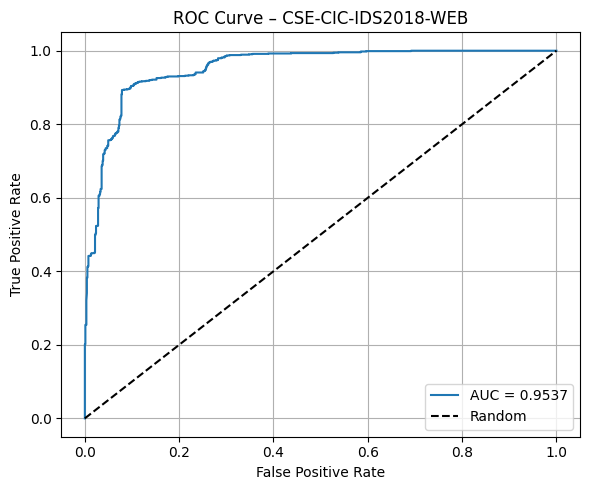

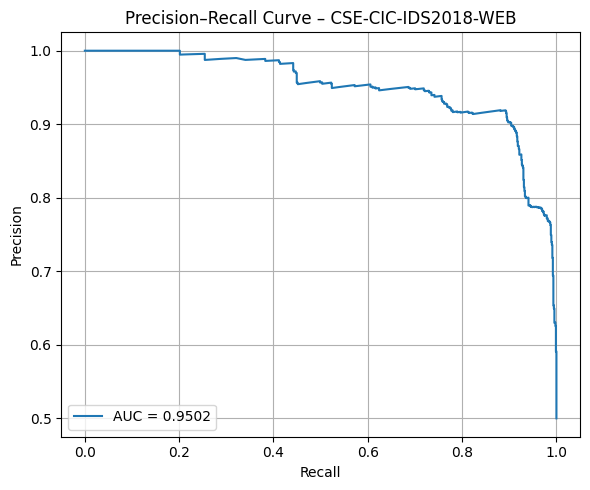

In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_dnn_kfold_with_plots(X_path, y_path, prefix, n_splits=5):
    # Load dataset
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Transform categorical columns
    categorical_cols = X.select_dtypes(include='object').columns
    le = LabelEncoder()
    for col in categorical_cols:
        le.fit(X[col])
        X[col] = le.transform(X[col])

    # Stratified k-fold (default: 5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Metric collectors
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Callbacks: Early Stopping & LR scheduler
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6)
    early_stopping = EarlyStopping(patience=10, restore_best_weights=True)

    fold = 1
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} has only one class. Skipped.")
            fold += 1
            continue

        # Build DNN model
        model = Sequential()
        model.add(Dense(256, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=l2(0.01)))  # 1st hidden layer
        model.add(BatchNormalization())
        model.add(Dropout(0.5))
        model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))  # 2nd hidden layer
        model.add(BatchNormalization())
        model.add(Dropout(0.5))
        model.add(Dense(64, activation='relu'))  # 3rd hidden layer
        model.add(Dense(1, activation='sigmoid'))  # Output layer (binary)

        # Compile
        model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

        # Train with early stopping and LR reduction
        model.fit(
            X_train, y_train,
            epochs=100, batch_size=64, verbose=0,
            validation_data=(X_test, y_test),
            callbacks=[early_stopping, reduce_lr]
        )

        # Predictions
        y_proba = model.predict(X_test, verbose=0).ravel()
        y_pred = (y_proba > 0.5).astype("int32")
        y_score = y_proba

        # Save for global curves
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Metrics
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completed.")
        fold += 1

    # Averages across folds
    print(f"\n📊 {prefix} — DNN (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # Combined curves
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # ROC plot
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # PR plot
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 👉 Example call:
run_dnn_kfold_with_plots('/content/IDS_X_web.csv', '/content/IDS_y_web.csv', 'CSE-CIC-IDS2018-WEB')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 1 completed.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 2 completed.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 3 completed.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 4 completed.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 5 completed.

📊 UNSW-NB15 — DNN (Stratified 5-Fold CV)
Accuracy:  0.9748 ± 0.0011
Precision: 0.6858 ± 0.0292
Recall:    0.4333 ± 0.0283
F1 Score:  0.5304 ± 0.0247
MCC:       0.5329 ± 0.0232
AUC-ROC:   0.9487
AUC-PR:    0.6372


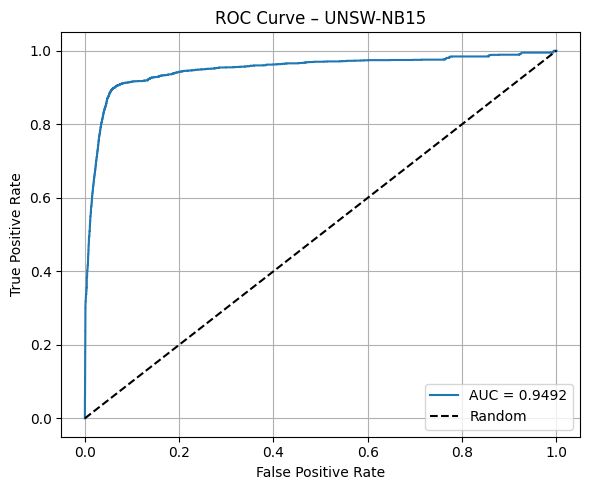

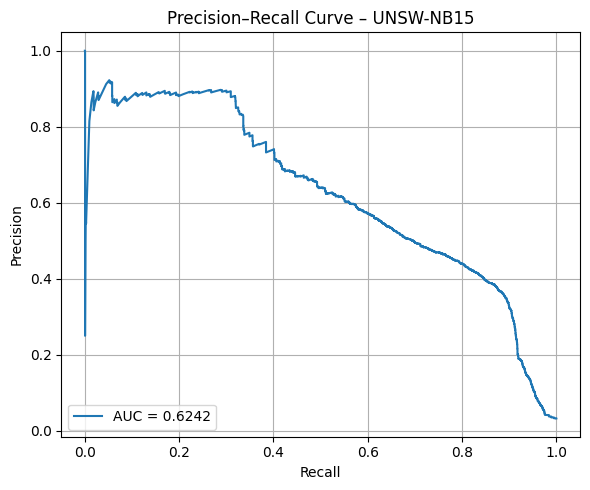

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_dnn_kfold_with_plots(X_path, y_path, prefix, n_splits=5, sample_frac=0.1):
    # Load dataset
    X = pd.read_csv(X_path, low_memory=False)
    y = pd.read_csv(y_path).squeeze()

    # Reset indices to avoid downstream alignment issues
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    # Subsample the dataset (adjust fraction as needed)
    sampled_indices = X.sample(frac=sample_frac, random_state=42).index
    X_sampled = X.loc[sampled_indices]  # keep alignment with .loc
    y_sampled = y.loc[sampled_indices]  # keep alignment with .loc

    # Transform categorical columns
    categorical_cols = X_sampled.select_dtypes(include='object').columns
    le = LabelEncoder()
    for col in categorical_cols:
        le.fit(X_sampled[col])
        X_sampled[col] = le.transform(X_sampled[col])

    # Stratified k-fold (default: 5 folds)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Metric collectors
    accs, precs, recs, f1s, mccs, aucs, pr_aucs = [], [], [], [], [], [], []
    all_y_true = []
    all_y_scores = []

    # Callbacks: Early Stopping & LR reduction
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6)
    early_stopping = EarlyStopping(patience=10, restore_best_weights=True)

    fold = 1
    for train_idx, test_idx in skf.split(X_sampled, y_sampled):
        X_train, X_test = X_sampled.iloc[train_idx], X_sampled.iloc[test_idx]
        y_train, y_test = y_sampled.iloc[train_idx], y_sampled.iloc[test_idx]

        if len(np.unique(y_train)) < 2:
            print(f"⚠️ Fold {fold} has only one class. Skipped.")
            fold += 1
            continue

        # Build DNN (Deep Neural Network)
        model = Sequential()
        model.add(Dense(256, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=l2(0.01)))  # 1st hidden layer
        model.add(BatchNormalization())  # normalization
        model.add(Dropout(0.5))  # dropout regularization
        model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))  # 2nd hidden layer
        model.add(BatchNormalization())
        model.add(Dropout(0.5))
        model.add(Dense(64, activation='relu'))  # 3rd hidden layer
        model.add(Dense(1, activation='sigmoid'))  # output layer (binary classification)

        # Compile
        model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

        # Train with early stopping and LR reduction
        model.fit(
            X_train, y_train,
            epochs=100, batch_size=64, verbose=0,
            validation_data=(X_test, y_test),
            callbacks=[early_stopping, reduce_lr]
        )

        # Predictions
        y_proba = model.predict(X_test, verbose=0).ravel()
        y_pred = (y_proba > 0.5).astype("int32")
        y_score = y_proba

        # Save predictions/scores for global curves
        all_y_true.extend(y_test)
        all_y_scores.extend(y_score)

        # Metrics
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred))
        recs.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        mccs.append(matthews_corrcoef(y_test, y_pred))
        aucs.append(roc_auc_score(y_test, y_score))
        pr_aucs.append(average_precision_score(y_test, y_score))

        print(f"✅ Fold {fold} completed.")
        fold += 1

    # Averages across folds
    print(f"\n📊 {prefix} — DNN (Stratified {n_splits}-Fold CV)")
    print(f"Accuracy:  {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
    print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")
    print(f"F1 Score:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"MCC:       {np.mean(mccs):.4f} ± {np.std(mccs):.4f}")
    print(f"AUC-ROC:   {np.mean(aucs):.4f}")
    print(f"AUC-PR:    {np.mean(pr_aucs):.4f}")

    # Combined curves
    fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)

    # ROC plot
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--', label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {prefix}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Precision–Recall plot
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve – {prefix}")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 👉 Example call:
run_dnn_kfold_with_plots('/content/UNSW_X.csv', '/content/UNSW_y.csv', 'UNSW-NB15')
